# Deep Learning
## Assignment 1
## Muhammad Hassan Khalid
## 21L-5692


# **Question 1**

Part a

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7134 - loss: 1.1232 - val_accuracy: 0.8790 - val_loss: 0.4788
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8772 - loss: 0.4752 - val_accuracy: 0.8955 - val_loss: 0.3996
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8905 - loss: 0.4091 - val_accuracy: 0.9036 - val_loss: 0.3673
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8984 - loss: 0.3775 - val_accuracy: 0.9070 - val_loss: 0.3479
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9001 - loss: 0.3636 - val_accuracy: 0.9102 - val_loss: 0.3348
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9044 - loss: 0.3526 - val_accuracy: 0.9107 - val_loss: 0.3269
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9062 - loss: 0.3394 - val_accuracy: 0.9129 - val_loss: 0.3198
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9052 - loss: 0.3381 - 

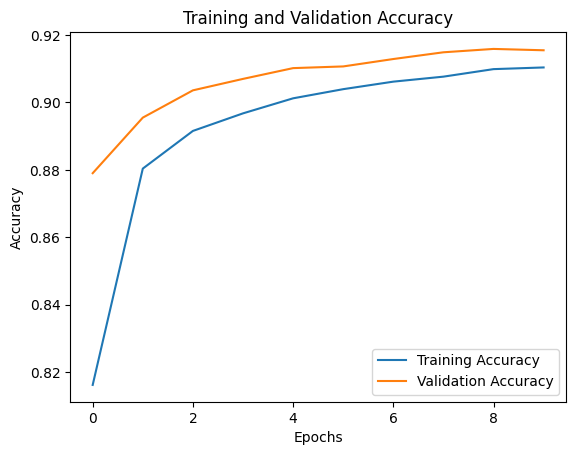

In [15]:
# Import libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Preprocessing data: flatten and normalize
x_train = x_train.reshape(-1, 28*28) / 255.0
x_test = x_test.reshape(-1, 28*28) / 255.0

# Converting labels to one-hot encoding
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# Logistic Regression Model (single layer)
model = Sequential([
    Dense(10, activation='softmax', input_shape=(28*28,))
])

# Compiling model with SGD optimizer
model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

# Training the model
history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test))

# Evaluating the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'Test accuracy: {test_acc:.4f}')

# Plot training & validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Part b


Training with SGD optimizer...
SGD - Test accuracy: 0.9159, Test loss: 0.3058

Training with SGD with Momentum optimizer...
SGD with Momentum - Test accuracy: 0.9241, Test loss: 0.2728

Training with NAG optimizer...
NAG - Test accuracy: 0.9232, Test loss: 0.2752

Training with Adagrad optimizer...
Adagrad - Test accuracy: 0.9168, Test loss: 0.2996

Training with RMSprop optimizer...
RMSprop - Test accuracy: 0.9270, Test loss: 0.2790

Training with Adam optimizer...
Adam - Test accuracy: 0.9289, Test loss: 0.2647


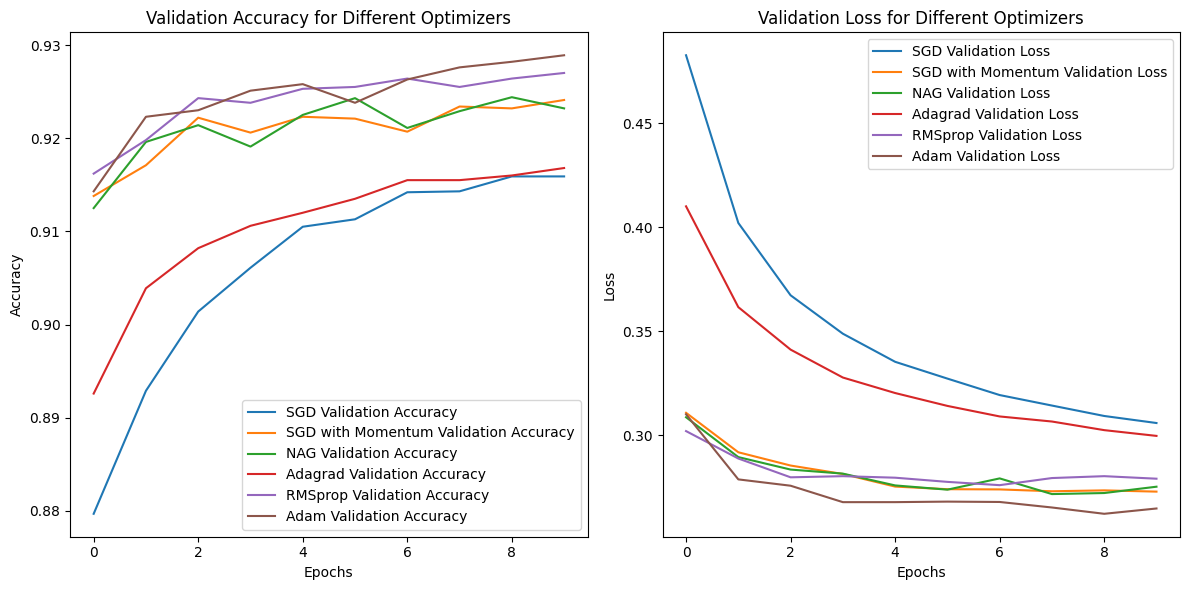

In [16]:
# Import libraries
import tensorflow as tf
from tensorflow.keras.optimizers import SGD, RMSprop, Adam, Adagrad
import matplotlib.pyplot as plt

# List of optimizers with configurations
optimizers = {
    'SGD': SGD(learning_rate=0.01),  # Vanilla SGD
    'SGD with Momentum': SGD(learning_rate=0.01, momentum=0.9),  # Momentum
    'NAG': SGD(learning_rate=0.01, momentum=0.9, nesterov=True),  # Nesterov Accelerated Gradient
    'Adagrad': Adagrad(learning_rate=0.01),  # Adagrad
    'RMSprop': RMSprop(learning_rate=0.001),  # RMSprop
    'Adam': Adam(learning_rate=0.001)  # Adam
}

histories = {}

# Loop through optimizers and train the model
for opt_name, opt in optimizers.items():
    print(f'\nTraining with {opt_name} optimizer...')

    # Building the same model structure
    model = Sequential([
        Dense(10, activation='softmax', input_shape=(28*28,))
    ])

    # Compiling the model with the selected optimizer
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    # Training the model
    history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test), verbose=0)
    histories[opt_name] = history

    # Evaluating the model
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print(f'{opt_name} - Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}')

# Plot comparison of optimizers - Accuracy
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
for opt_name in optimizers:
    plt.plot(histories[opt_name].history['val_accuracy'], label=f'{opt_name} Validation Accuracy')
plt.title('Validation Accuracy for Different Optimizers')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot comparison of optimizers - Loss
plt.subplot(1, 2, 2)
for opt_name in optimizers:
    plt.plot(histories[opt_name].history['val_loss'], label=f'{opt_name} Validation Loss')
plt.title('Validation Loss for Different Optimizers')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Part c

Install Library

In [3]:
pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.4 MB/s eta 0:00:00


In [5]:
# Import libraries
import keras_tuner as kt
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# Building a custom HyperModel
class MyHyperModel(kt.HyperModel):
    def build(self, hp):
        model = Sequential()
        model.add(Flatten(input_shape=(28 * 28,)))  # Input layer for flattened MNIST images
        model.add(
            Dense(
                units=hp.Int("units", min_value=32, max_value=512, step=32),
                activation="relu",
            )
        )
        model.add(Dense(10, activation="softmax"))  # Output layer for 10 classes
        model.compile(
            optimizer=Adam(learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
            loss="categorical_crossentropy",
            metrics=["accuracy"],
        )
        return model

    def fit(self, hp, model, *args, **kwargs):
        return model.fit(
            *args,
            batch_size=hp.Choice("batch_size", [16, 32, 64]),  # Tuning batch size
            **kwargs,
        )

# Initializing the tuner
tuner = kt.RandomSearch(
    MyHyperModel(),
    objective="val_accuracy",
    max_trials=10,
    overwrite=True,
    directory="my_dir",
    project_name="tune_hypermodel",
)

# Load dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.reshape(-1, 28 * 28).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28 * 28).astype("float32") / 255.0
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

# Searching for the best hyperparameters
tuner.search(
    x_train, y_train,
    epochs=30,  # Set maximum epoch limit
    validation_data=(x_test, y_test),
    callbacks=[tf.keras.callbacks.EarlyStopping('val_loss', patience=3)]  # Early stopping
)

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters()[0]
print(f"Best hyperparameters: Learning rate = {best_hps.get('learning_rate')}, "
      f"Batch size = {best_hps.get('batch_size')}, "
      f"Units = {best_hps.get('units')}")

# Building and retraing the model with the best hyperparameters
model = tuner.hypermodel.build(best_hps)
history = model.fit(x_train, y_train, epochs=30, batch_size=best_hps.get('batch_size'),
                    validation_data=(x_test, y_test))

# Evaluating the tuned model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'Tuned model accuracy: {test_acc:.4f}')

Trial 10 Complete [00h 02m 13s]
val_accuracy: 0.9663000106811523

Best val_accuracy So Far: 0.9822999835014343
Total elapsed time: 00h 30m 31s
Best hyperparameters: Learning rate = 0.001, Batch size = 16, Units = 320
Epoch 1/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.9058 - loss: 0.3250 - val_accuracy: 0.9682 - val_loss: 0.1009
Epoch 2/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.9743 - loss: 0.0840 - val_accuracy: 0.9698 - val_loss: 0.0936
Epoch 3/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.9832 - loss: 0.0526 - val_accuracy: 0.9748 - val_loss: 0.0770
Epoch 4/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.9884 - loss: 0.0355 - val_accuracy: 0.9761 - val_loss: 0.0838
Epoch 5/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.9909 - loss: 0.0278 - val_accuracy: 0.9781 - val_loss: 0.0777
Epoch 6/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.9925 - loss: 0.0219 - val_accuracy: 0.9760 - val_loss: 0.08

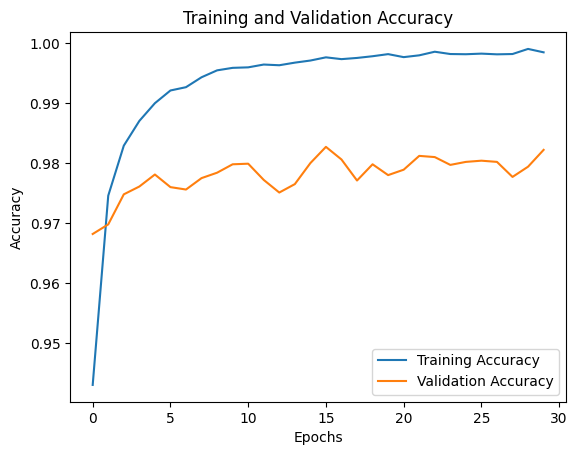

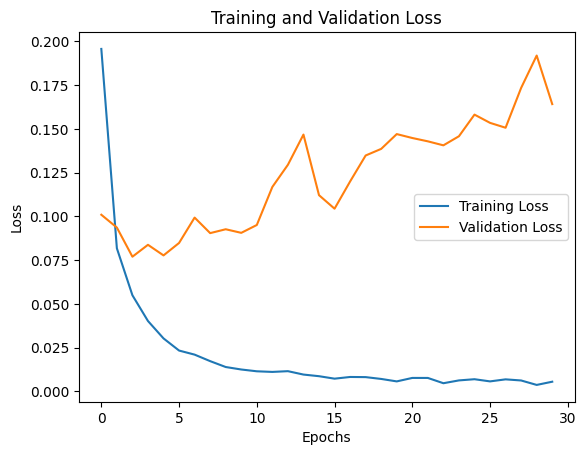

In [6]:
import matplotlib.pyplot as plt

# Plotting accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

# Plotting loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


# Question 2

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8768 - loss: 0.4369 - val_accuracy: 0.9633 - val_loss: 0.1273
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9637 - loss: 0.1222 - val_accuracy: 0.9727 - val_loss: 0.0919
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9764 - loss: 0.0785 - val_accuracy: 0.9733 - val_loss: 0.0884
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9825 - loss: 0.0601 - val_accuracy: 0.9728 - val_loss: 0.0828
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9861 - loss: 0.0450 - val_accuracy: 0.9778 - val_loss: 0.0724
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9893 - loss: 0.0339 - val_accuracy: 0.9779 - val_loss: 0.0708
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9912 - loss: 0.0273 - val_accuracy: 0.9796 - val_loss: 0.0728
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9937 - loss: 0.02

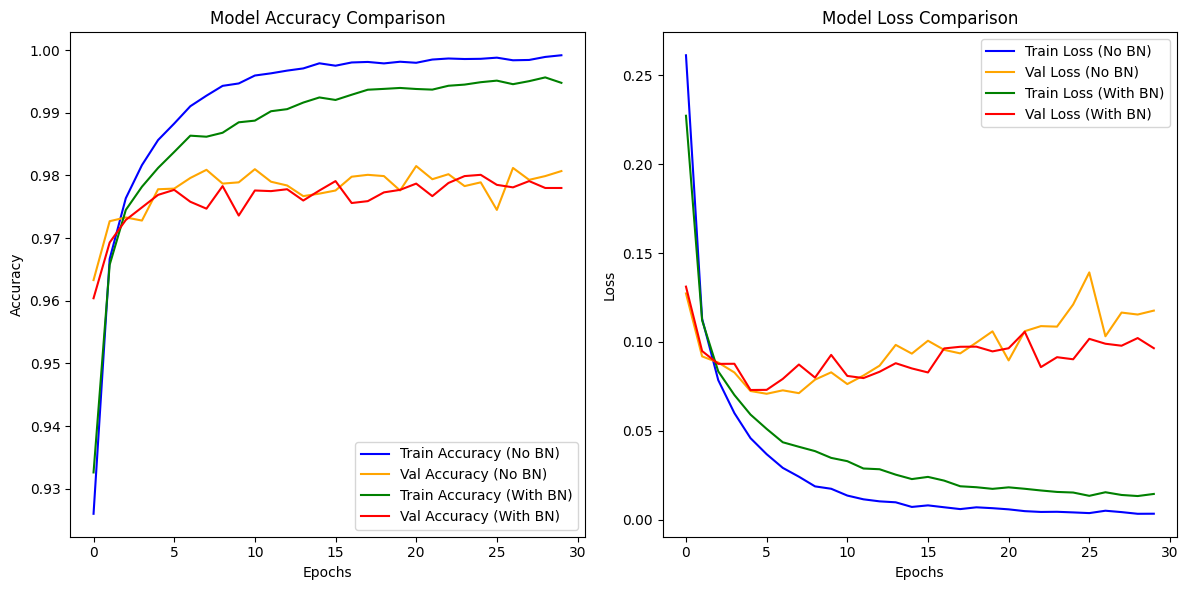

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9749 - loss: 0.1131
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9773 - loss: 0.1495
Test accuracy with Batch Normalization: 0.9780, Loss: 0.0965
Test accuracy without Batch Normalization: 0.9807, Loss: 0.1177


In [12]:
# Import libraries
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, BatchNormalization
import matplotlib.pyplot as plt

# Loading and preprocessing the data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.reshape(-1, 28 * 28).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28 * 28).astype("float32") / 255.0
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

# Function to build a model with or without batch normalization
def build_model(use_batch_norm=False):
    model = Sequential()
    model.add(Flatten(input_shape=(28 * 28,)))
    model.add(Dense(128, activation='relu'))

    # Adding batch normalization layer
    if use_batch_norm:
        model.add(BatchNormalization())

    model.add(Dense(10, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Training model without batch normalization
model_without_bn = build_model(use_batch_norm=False)
history_without_bn = model_without_bn.fit(x_train, y_train, epochs=30,
                                           batch_size=32,
                                           validation_data=(x_test, y_test))

# Training model with batch normalization
model_with_bn = build_model(use_batch_norm=True)
history_with_bn = model_with_bn.fit(x_train, y_train, epochs=30,
                                     batch_size=32,
                                     validation_data=(x_test, y_test))

# Plot training and validation accuracy
plt.figure(figsize=(12, 6))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history_without_bn.history['accuracy'], label='Train Accuracy (No BN)', color='blue')
plt.plot(history_without_bn.history['val_accuracy'], label='Val Accuracy (No BN)', color='orange')
plt.plot(history_with_bn.history['accuracy'], label='Train Accuracy (With BN)', color='green')
plt.plot(history_with_bn.history['val_accuracy'], label='Val Accuracy (With BN)', color='red')
plt.title('Model Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history_without_bn.history['loss'], label='Train Loss (No BN)', color='blue')
plt.plot(history_without_bn.history['val_loss'], label='Val Loss (No BN)', color='orange')
plt.plot(history_with_bn.history['loss'], label='Train Loss (With BN)', color='green')
plt.plot(history_with_bn.history['val_loss'], label='Val Loss (With BN)', color='red')
plt.title('Model Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Evaluating both models
test_loss_bn, test_acc_bn = model_with_bn.evaluate(x_test, y_test)
test_loss_no_bn, test_acc_no_bn = model_without_bn.evaluate(x_test, y_test)

print(f'Test accuracy with Batch Normalization: {test_acc_bn:.4f}, Loss: {test_loss_bn:.4f}')
print(f'Test accuracy without Batch Normalization: {test_acc_no_bn:.4f}, Loss: {test_loss_no_bn:.4f}')

# Question 3

NOTE NO DATASET WAS PROVIDED

Batch GD Iteration 0: Loss = 11.0074
Batch GD Iteration 100: Loss = 0.9329
Batch GD Iteration 200: Loss = 0.9327
Batch GD Iteration 300: Loss = 0.9327
Batch GD Iteration 400: Loss = 0.9327
Batch GD Iteration 500: Loss = 0.9327
Batch GD Iteration 600: Loss = 0.9327
Batch GD Iteration 700: Loss = 0.9327
Batch GD Iteration 800: Loss = 0.9327
Batch GD Iteration 900: Loss = 0.9327
SGD Iteration 0: Loss = 12.2383
SGD Iteration 100: Loss = 1.5393
SGD Iteration 200: Loss = 1.5506
SGD Iteration 300: Loss = 1.2255
SGD Iteration 400: Loss = 1.0764
SGD Iteration 500: Loss = 1.4359
SGD Iteration 600: Loss = 0.9979
SGD Iteration 700: Loss = 1.4089
SGD Iteration 800: Loss = 1.5519
SGD Iteration 900: Loss = 1.2670
Mini-batch GD Iteration 0: Loss = 12.2244
Mini-batch GD Iteration 100: Loss = 0.9328
Mini-batch GD Iteration 200: Loss = 0.9343
Mini-batch GD Iteration 300: Loss = 0.9777
Mini-batch GD Iteration 400: Loss = 0.9580
Mini-batch GD Iteration 500: Loss = 0.9466
Mini-batch GD Iteration 600: Loss =

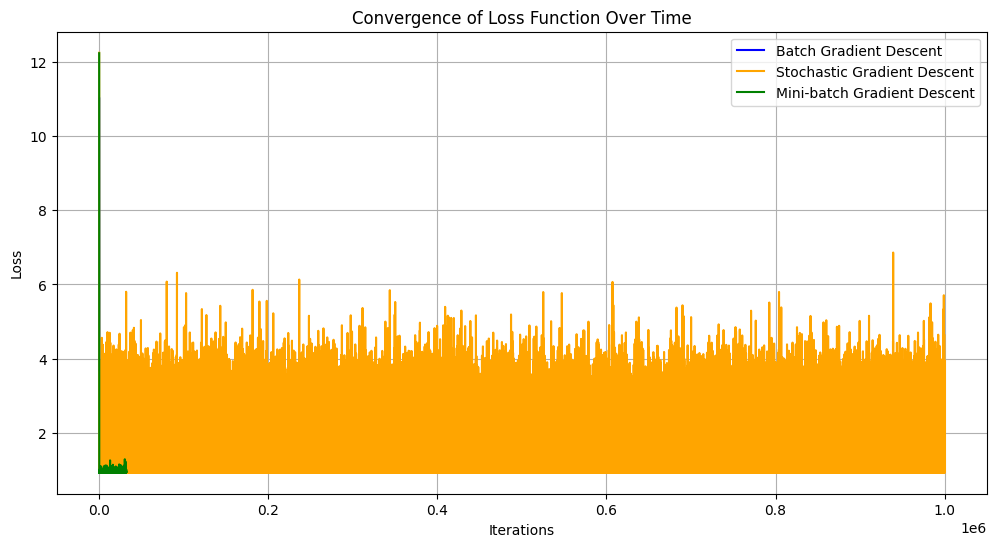

In [13]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

# Generating synthetic data for linear regression
np.random.seed(0)
X = 2 * np.random.rand(1000, 1)
y = 4 + 3 * X + np.random.randn(1000, 1)

# Preparing the data (adding bias term)
X_b = np.c_[np.ones((X.shape[0], 1)), X]

# Gradient Descent Functions
def compute_loss(X, y, theta):
    return np.mean((X @ theta - y) ** 2)

def batch_gradient_descent(X, y, learning_rate=0.1, n_iterations=1000):
    m = len(y)
    theta = np.random.randn(2, 1)  # random initialization
    losses = []

    for iteration in range(n_iterations):
        gradients = 2/m * X.T @ (X @ theta - y)
        theta -= learning_rate * gradients
        loss = compute_loss(X, y, theta)
        losses.append(loss)

        if iteration % 100 == 0:  # Printing loss every 100 iterations
            print(f'Batch GD Iteration {iteration}: Loss = {loss:.4f}')

    return theta, losses

def stochastic_gradient_descent(X, y, learning_rate=0.1, n_iterations=1000):
    m = len(y)
    theta = np.random.randn(2, 1)  # random initialization
    losses = []

    for iteration in range(n_iterations):
        for i in range(m):
            random_index = np.random.randint(m)
            xi = X[random_index:random_index + 1]
            yi = y[random_index:random_index + 1]
            gradients = 2 * xi.T @ (xi @ theta - yi)
            theta -= learning_rate * gradients
            loss = compute_loss(X, y, theta)
            losses.append(loss)

            if iteration % 100 == 0 and i == 0:  # Printing loss every 100 iterations
                print(f'SGD Iteration {iteration}: Loss = {loss:.4f}')

    return theta, losses

def mini_batch_gradient_descent(X, y, learning_rate=0.1, n_iterations=1000, batch_size=32):
    m = len(y)
    theta = np.random.randn(2, 1)  # random initialization
    losses = []

    for iteration in range(n_iterations):
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(0, m, batch_size):
            xi = X_shuffled[i:i + batch_size]
            yi = y_shuffled[i:i + batch_size]
            gradients = 2/len(xi) * xi.T @ (xi @ theta - yi)
            theta -= learning_rate * gradients

            loss = compute_loss(X, y, theta)
            losses.append(loss)

            if iteration % 100 == 0 and i == 0:  # Printing loss every 100 iterations
                print(f'Mini-batch GD Iteration {iteration}: Loss = {loss:.4f}')

    return theta, losses

# Hyperparameters
learning_rate = 0.1
n_iterations = 1000
batch_size = 32

# Training the models
theta_batch, losses_batch = batch_gradient_descent(X_b, y, learning_rate, n_iterations)
theta_sgd, losses_sgd = stochastic_gradient_descent(X_b, y, learning_rate, n_iterations)
theta_mini_batch, losses_mini_batch = mini_batch_gradient_descent(X_b, y, learning_rate, n_iterations, batch_size)

# Plotting the convergence of loss
plt.figure(figsize=(12, 6))
plt.plot(losses_batch, label='Batch Gradient Descent', color='blue')
plt.plot(losses_sgd, label='Stochastic Gradient Descent', color='orange')
plt.plot(losses_mini_batch, label='Mini-batch Gradient Descent', color='green')
plt.title('Convergence of Loss Function Over Time')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

# Question 4

In [4]:
# Import libraries
import keras_tuner as kt
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# Building a custom HyperModel
class MyHyperModel(kt.HyperModel):
    def build(self, hp):
        model = Sequential()
        model.add(Flatten(input_shape=(28 * 28,)))

        # Tuning the number of layers and units in each layer
        for i in range(hp.Int("num_layers", 1, 3)):  # Tuning between 1 and 3 layers
            model.add(
                Dense(
                    units=hp.Int("units_" + str(i), min_value=32, max_value=512, step=32),
                    activation="relu",
                )
            )
            # Adding dropout layer
            if hp.Choice("dropout_rate", [0.0, 0.2, 0.5]) > 0.0:
                model.add(Dropout(rate=hp.Choice("dropout_rate", [0.0, 0.2, 0.5])))

        model.add(Dense(10, activation="softmax"))  # Output layer for 10 classes
        model.compile(
            optimizer=Adam(learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
            loss="categorical_crossentropy",
            metrics=["accuracy"],
        )
        return model

    def fit(self, hp, model, *args, **kwargs):
        return model.fit(
            *args,
            batch_size=hp.Choice("batch_size", [16, 32, 64]),  # Tuning batch size
            **kwargs,
        )

# Initializing the tuner
tuner = kt.RandomSearch(
    MyHyperModel(),
    objective="val_accuracy",
    max_trials=10,
    overwrite=True,
    directory="my_dir",
    project_name="tune_hypermodel",
)

# Load dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.reshape(-1, 28 * 28).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28 * 28).astype("float32") / 255.0
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

# Searching for the best hyperparameters
tuner.search(
    x_train, y_train,
    epochs=30,  # Set a maximum epoch limit
    validation_data=(x_test, y_test),
    callbacks=[tf.keras.callbacks.EarlyStopping('val_loss', patience=3)]  # Early stopping
)

# Getting the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters()[0]
print(f"Best hyperparameters: Learning rate = {best_hps.get('learning_rate')}, "
      f"Batch size = {best_hps.get('batch_size')}, "
      f"Units = {[best_hps.get('units_' + str(i)) for i in range(best_hps.get('num_layers'))]}")

# Building and retraining the model with the best hyperparameters
model = tuner.hypermodel.build(best_hps)
history = model.fit(x_train, y_train, epochs=30, batch_size=best_hps.get('batch_size'),
                    validation_data=(x_test, y_test))

# Evaluating the tuned model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'Tuned model accuracy: {test_acc:.4f}')

Trial 10 Complete [00h 13m 38s]
val_accuracy: 0.9815000295639038

Best val_accuracy So Far: 0.9839000105857849
Total elapsed time: 00h 50m 47s
Best hyperparameters: Learning rate = 0.0001, Batch size = 16, Units = [320, 96]
Epoch 1/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step - accuracy: 0.7604 - loss: 0.8151 - val_accuracy: 0.9406 - val_loss: 0.2032
Epoch 2/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9336 - loss: 0.2309 - val_accuracy: 0.9585 - val_loss: 0.1410
Epoch 3/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 42s 6ms/step - accuracy: 0.9515 - loss: 0.1660 - val_accuracy: 0.9665 - val_loss: 0.1103
Epoch 4/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 41s 6ms/step - accuracy: 0.9620 - loss: 0.1292 - val_accuracy: 0.9706 - val_loss: 0.0944
Epoch 5/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 41s 6ms/step - accuracy: 0.9682 - loss: 0.1048 - val_accuracy: 0.9721 - val_loss: 0.0853
Epoch 6/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 41s 6ms/step - accuracy: 0.9730 - loss: 0.0903 - val_accuracy: 0.9762 - val_los

AttributeError: 'MetricsTracker' object has no attribute 'get'

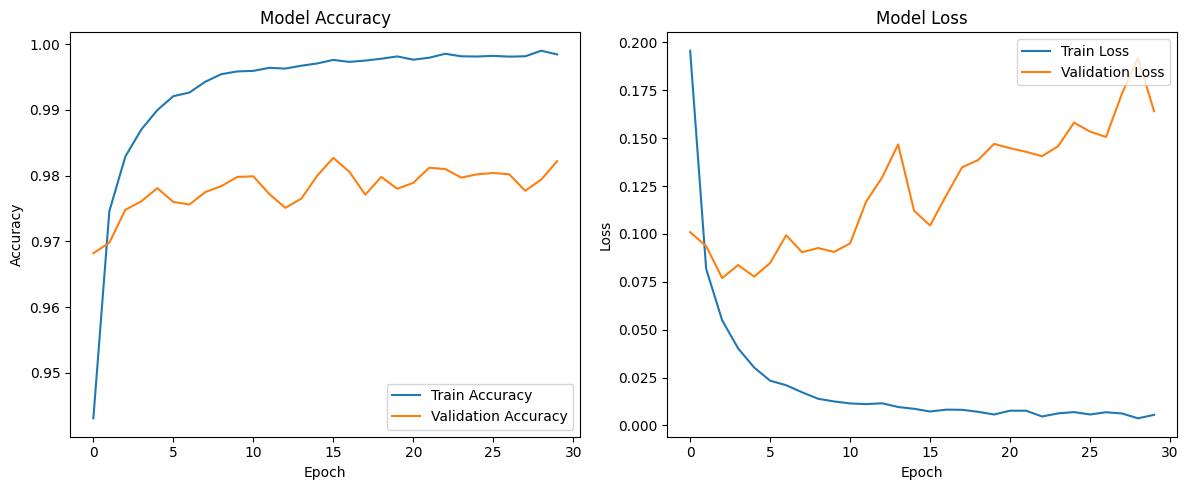

In [8]:
import matplotlib.pyplot as plt

def plot_history(history):
    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='lower right')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

plot_history(history)